# RNN vs LSTM vs BiLSTM 比較實驗

**資料集：** SMS Spam Collection（~5,574 筆，二元分類：ham / spam）  
**任務：** 在完全相同的超參數與訓練集下，比較單向 RNN、單向 LSTM、雙向 BiLSTM 三種模型的表現。

| 超參數 | 數值 |
|--------|------|
| Learning Rate | 0.001 |
| Epochs | 15 |
| Hidden Size | 128 |
| Embedding Dim | 64 |
| Num Layers | 2 |
| Batch Size | 32 |
| Dropout | 0.3 |

## 1. 套件匯入

In [1]:
import os
import re
import zipfile
import urllib.request
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib
from sklearn.metrics import f1_score, accuracy_score

matplotlib.rcParams['font.family'] = ['Microsoft JhengHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

print('PyTorch 版本:', torch.__version__)
print('CUDA 可用:', torch.cuda.is_available())

PyTorch 版本: 2.6.0+cu126
CUDA 可用: True


## 2. 超參數設定（三個模型完全相同）

In [2]:
SEED          = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

LEARNING_RATE = 0.001
EPOCHS        = 15
HIDDEN_SIZE   = 128
EMBED_DIM     = 64
NUM_LAYERS    = 2
BATCH_SIZE    = 32
DROPOUT       = 0.3
MAX_LEN       = 50
MIN_FREQ      = 2

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('使用裝置:', DEVICE)

使用裝置: cuda


## 3. 下載並載入資料集

In [3]:
def download_dataset(save_dir='data'):
    os.makedirs(save_dir, exist_ok=True)
    txt_path = os.path.join(save_dir, 'SMSSpamCollection')
    if os.path.exists(txt_path):
        print('資料集已存在，跳過下載。')
        return txt_path
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip'
    zip_path = os.path.join(save_dir, 'sms.zip')
    print('正在下載 SMS Spam Collection ...')
    urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(save_dir)
    os.remove(zip_path)
    print('下載完成！')
    return txt_path


def load_data(txt_path):
    texts, labels = [], []
    with open(txt_path, encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split('\t', 1)
            if len(parts) == 2:
                label_str, text = parts
                labels.append(1 if label_str == 'spam' else 0)
                texts.append(text.lower())
    return texts, labels


txt_path = download_dataset()
texts, labels = load_data(txt_path)
print(f'總筆數: {len(texts)} | spam: {sum(labels)} | ham: {len(labels) - sum(labels)}')

資料集已存在，跳過下載。
總筆數: 5574 | spam: 747 | ham: 4827


## 4. 資料預處理

In [4]:
def simple_tokenize(text):
    return re.findall(r"[a-z0-9']+", text)


class Vocabulary:
    PAD, UNK = '<pad>', '<unk>'

    def __init__(self, min_freq=MIN_FREQ):
        self.min_freq = min_freq
        self.word2idx = {self.PAD: 0, self.UNK: 1}
        self.idx2word = [self.PAD, self.UNK]

    def build(self, tokenized_texts):
        counter = Counter(tok for toks in tokenized_texts for tok in toks)
        for word, cnt in counter.items():
            if cnt >= self.min_freq:
                self.word2idx[word] = len(self.idx2word)
                self.idx2word.append(word)

    def encode(self, tokens, max_len=MAX_LEN):
        ids = [self.word2idx.get(t, 1) for t in tokens[:max_len]]
        return ids if ids else [1]

    def __len__(self):
        return len(self.idx2word)


class SMSDataset(Dataset):
    def __init__(self, texts, labels, vocab):
        self.samples = [
            (torch.tensor(vocab.encode(simple_tokenize(t)), dtype=torch.long), lbl)
            for t, lbl in zip(texts, labels)
        ]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


def collate_fn(batch):
    seqs, labels = zip(*batch)
    return pad_sequence(seqs, batch_first=True, padding_value=0), \
           torch.tensor(labels, dtype=torch.long)


def split_data(texts, labels, train_r=0.8, val_r=0.1):
    n = len(texts)
    idx = list(range(n))
    random.shuffle(idx)
    t = int(n * train_r)
    v = int(n * (train_r + val_r))
    def sel(lst, ids): return [lst[i] for i in ids]
    return (sel(texts, idx[:t]),  sel(labels, idx[:t]),
            sel(texts, idx[t:v]), sel(labels, idx[t:v]),
            sel(texts, idx[v:]),  sel(labels, idx[v:]))


(tr_texts, tr_labels,
 va_texts, va_labels,
 te_texts, te_labels) = split_data(texts, labels)

vocab = Vocabulary()
vocab.build([simple_tokenize(t) for t in tr_texts])

def make_loader(txts, lbls, shuffle):
    ds = SMSDataset(txts, lbls, vocab)
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle, collate_fn=collate_fn)

train_loader = make_loader(tr_texts, tr_labels, shuffle=True)
val_loader   = make_loader(va_texts, va_labels, shuffle=False)
test_loader  = make_loader(te_texts, te_labels, shuffle=False)

print(f'Train: {len(tr_texts)} | Val: {len(va_texts)} | Test: {len(te_texts)}')
print(f'詞彙表大小: {len(vocab)}')

Train: 4459 | Val: 557 | Test: 558
詞彙表大小: 3780


## 5. 模型定義

統一使用 `SequenceClassifier`，透過參數切換三種架構：

| 模型 | `rnn_type` | `bidirectional` | FC 輸入維度 |
|------|-----------|-----------------|-------------|
| 單向 RNN (GRU) | `'GRU'` | `False` | `HIDDEN_SIZE` |
| 單向 LSTM | `'LSTM'` | `False` | `HIDDEN_SIZE` |
| 雙向 BiLSTM | `'LSTM'` | `True` | `HIDDEN_SIZE × 2` |

LSTM 回傳 `(output, (h_n, c_n))`，取 `h_n` 最後一層作為句子表示；BiLSTM 則拼接前向與後向的最後層 hidden state。

In [5]:
class SequenceClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, num_layers,
                 num_classes=2, dropout=DROPOUT,
                 rnn_type='GRU', bidirectional=False):
        super().__init__()
        self.rnn_type     = rnn_type
        self.bidirectional = bidirectional

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        rnn_cls = nn.LSTM if rnn_type == 'LSTM' else nn.GRU
        self.rnn = rnn_cls(
            input_size=embed_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional
        )
        direction = 2 if bidirectional else 1
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size * direction, num_classes)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))          # (B, T, E)
        out = self.rnn(emb)
        # LSTM 回傳 (output, (h_n, c_n))；GRU 回傳 (output, h_n)
        hidden = out[1][0] if self.rnn_type == 'LSTM' else out[1]
        if self.bidirectional:
            hidden = torch.cat([hidden[-2], hidden[-1]], dim=1)  # (B, 2H)
        else:
            hidden = hidden[-1]                                   # (B, H)
        return self.fc(self.dropout(hidden))


VOCAB_SIZE = len(vocab)

rnn_model   = SequenceClassifier(VOCAB_SIZE, EMBED_DIM, HIDDEN_SIZE, NUM_LAYERS,
                                  rnn_type='GRU',  bidirectional=False).to(DEVICE)
lstm_model  = SequenceClassifier(VOCAB_SIZE, EMBED_DIM, HIDDEN_SIZE, NUM_LAYERS,
                                  rnn_type='LSTM', bidirectional=False).to(DEVICE)
bilstm_model= SequenceClassifier(VOCAB_SIZE, EMBED_DIM, HIDDEN_SIZE, NUM_LAYERS,
                                  rnn_type='LSTM', bidirectional=True ).to(DEVICE)

for name, m in [('單向 RNN (GRU)', rnn_model),
                ('單向 LSTM',      lstm_model),
                ('雙向 BiLSTM',    bilstm_model)]:
    print(f'{name:16s}  參數量: {sum(p.numel() for p in m.parameters()):>10,}')

單向 RNN (GRU)      參數量:    415,746
單向 LSTM           參數量:    473,602
雙向 BiLSTM         參數量:    836,354


## 6. 訓練與評估函式

In [6]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * y.size(0)
        correct    += (logits.argmax(1) == y).sum().item()
        total      += y.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, preds, trues = 0.0, [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)
            total_loss += criterion(logits, y).item() * y.size(0)
            preds.extend(logits.argmax(1).cpu().numpy())
            trues.extend(y.cpu().numpy())
    n = len(trues)
    return total_loss / n, accuracy_score(trues, preds), f1_score(trues, preds, average='macro')


def train_model(model, name):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
    tr_losses, va_losses = [], []

    print(f"\n{'='*58}")
    print(f"  訓練：{name}")
    print(f"{'='*58}")
    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc        = train_epoch(model, train_loader, criterion, optimizer)
        va_loss, va_acc, va_f1 = evaluate(model, val_loader, criterion)
        scheduler.step()
        tr_losses.append(tr_loss)
        va_losses.append(va_loss)
        print(f"  Epoch {epoch:2d}/{EPOCHS} | "
              f"Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.3f} | "
              f"Val Loss: {va_loss:.4f}  Acc: {va_acc:.3f}  F1: {va_f1:.3f}")
    return tr_losses, va_losses


print('函式定義完成。')

函式定義完成。


## 7. 訓練單向 RNN (GRU)

In [7]:
rnn_tr_loss, rnn_va_loss = train_model(rnn_model, '單向 RNN (GRU)')


  訓練：單向 RNN (GRU)
  Epoch  1/15 | Train Loss: 0.3269  Acc: 0.876 | Val Loss: 0.2178  Acc: 0.914  F1: 0.785
  Epoch  2/15 | Train Loss: 0.1225  Acc: 0.959 | Val Loss: 0.0694  Acc: 0.977  F1: 0.954
  Epoch  3/15 | Train Loss: 0.0935  Acc: 0.971 | Val Loss: 0.1403  Acc: 0.966  F1: 0.928
  Epoch  4/15 | Train Loss: 0.0660  Acc: 0.984 | Val Loss: 0.0831  Acc: 0.977  F1: 0.952
  Epoch  5/15 | Train Loss: 0.0514  Acc: 0.986 | Val Loss: 0.0597  Acc: 0.982  F1: 0.965
  Epoch  6/15 | Train Loss: 0.0427  Acc: 0.989 | Val Loss: 0.0454  Acc: 0.986  F1: 0.972
  Epoch  7/15 | Train Loss: 0.0358  Acc: 0.991 | Val Loss: 0.0440  Acc: 0.991  F1: 0.982
  Epoch  8/15 | Train Loss: 0.0308  Acc: 0.993 | Val Loss: 0.0406  Acc: 0.991  F1: 0.982
  Epoch  9/15 | Train Loss: 0.0285  Acc: 0.993 | Val Loss: 0.0496  Acc: 0.987  F1: 0.975
  Epoch 10/15 | Train Loss: 0.0285  Acc: 0.991 | Val Loss: 0.0472  Acc: 0.987  F1: 0.975
  Epoch 11/15 | Train Loss: 0.0196  Acc: 0.995 | Val Loss: 0.0509  Acc: 0.986  F1: 0.972
  

## 8. 訓練單向 LSTM

In [8]:
lstm_tr_loss, lstm_va_loss = train_model(lstm_model, '單向 LSTM')


  訓練：單向 LSTM
  Epoch  1/15 | Train Loss: 0.3016  Acc: 0.893 | Val Loss: 0.1794  Acc: 0.937  F1: 0.858
  Epoch  2/15 | Train Loss: 0.1457  Acc: 0.950 | Val Loss: 0.1187  Acc: 0.968  F1: 0.933
  Epoch  3/15 | Train Loss: 0.1087  Acc: 0.967 | Val Loss: 0.0936  Acc: 0.978  F1: 0.959
  Epoch  4/15 | Train Loss: 0.0914  Acc: 0.975 | Val Loss: 0.1373  Acc: 0.946  F1: 0.907
  Epoch  5/15 | Train Loss: 0.0861  Acc: 0.977 | Val Loss: 0.1454  Acc: 0.964  F1: 0.933
  Epoch  6/15 | Train Loss: 0.0565  Acc: 0.986 | Val Loss: 0.0654  Acc: 0.982  F1: 0.966
  Epoch  7/15 | Train Loss: 0.0517  Acc: 0.989 | Val Loss: 0.0651  Acc: 0.984  F1: 0.968
  Epoch  8/15 | Train Loss: 0.0489  Acc: 0.989 | Val Loss: 0.0649  Acc: 0.984  F1: 0.969
  Epoch  9/15 | Train Loss: 0.0468  Acc: 0.988 | Val Loss: 0.0437  Acc: 0.991  F1: 0.982
  Epoch 10/15 | Train Loss: 0.0472  Acc: 0.988 | Val Loss: 0.0511  Acc: 0.989  F1: 0.979
  Epoch 11/15 | Train Loss: 0.0398  Acc: 0.989 | Val Loss: 0.0559  Acc: 0.989  F1: 0.979
  Epoch

## 9. 訓練雙向 BiLSTM

In [9]:
bilstm_tr_loss, bilstm_va_loss = train_model(bilstm_model, '雙向 BiLSTM')


  訓練：雙向 BiLSTM
  Epoch  1/15 | Train Loss: 0.2501  Acc: 0.905 | Val Loss: 0.2090  Acc: 0.932  F1: 0.850
  Epoch  2/15 | Train Loss: 0.1065  Acc: 0.966 | Val Loss: 0.1439  Acc: 0.957  F1: 0.916
  Epoch  3/15 | Train Loss: 0.0855  Acc: 0.976 | Val Loss: 0.1498  Acc: 0.962  F1: 0.922
  Epoch  4/15 | Train Loss: 0.0640  Acc: 0.982 | Val Loss: 0.1061  Acc: 0.969  F1: 0.938
  Epoch  5/15 | Train Loss: 0.0499  Acc: 0.986 | Val Loss: 0.0871  Acc: 0.971  F1: 0.946
  Epoch  6/15 | Train Loss: 0.0390  Acc: 0.989 | Val Loss: 0.0890  Acc: 0.975  F1: 0.949
  Epoch  7/15 | Train Loss: 0.0313  Acc: 0.990 | Val Loss: 0.0775  Acc: 0.980  F1: 0.960
  Epoch  8/15 | Train Loss: 0.0252  Acc: 0.993 | Val Loss: 0.0728  Acc: 0.984  F1: 0.968
  Epoch  9/15 | Train Loss: 0.0170  Acc: 0.993 | Val Loss: 0.0737  Acc: 0.986  F1: 0.972
  Epoch 10/15 | Train Loss: 0.0177  Acc: 0.995 | Val Loss: 0.0575  Acc: 0.987  F1: 0.976
  Epoch 11/15 | Train Loss: 0.0141  Acc: 0.996 | Val Loss: 0.0702  Acc: 0.984  F1: 0.968
  Epo

## 10. Loss 下降曲線

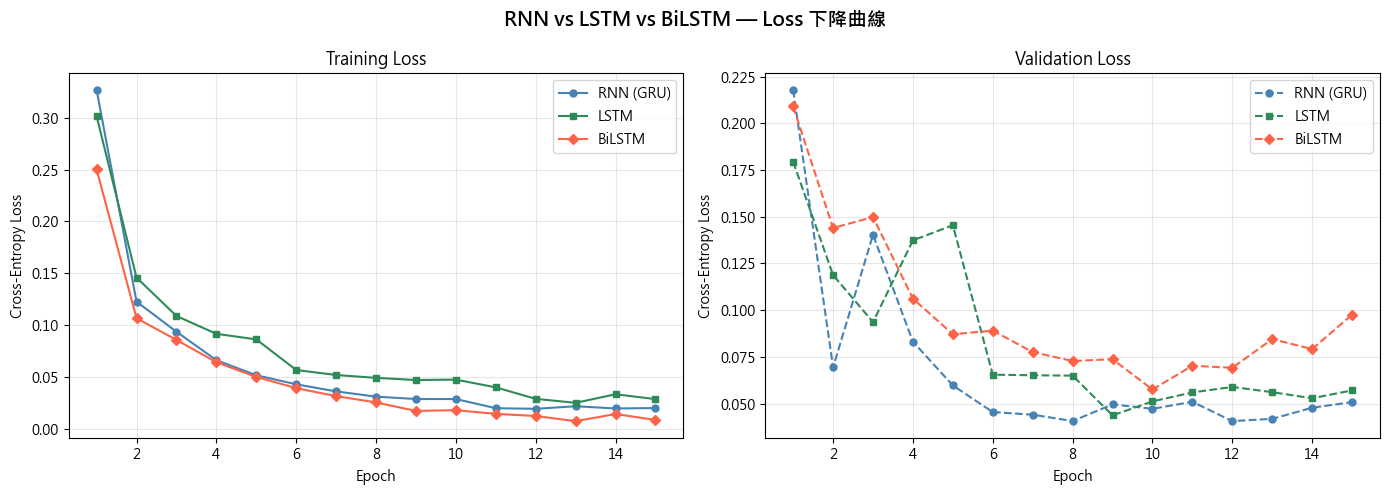

Loss 曲線已儲存為 loss_curves_3models.png


In [10]:
epochs_range = range(1, EPOCHS + 1)
colors = {'RNN': 'steelblue', 'LSTM': 'seagreen', 'BiLSTM': 'tomato'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('RNN vs LSTM vs BiLSTM — Loss 下降曲線', fontsize=14, fontweight='bold')

# Training Loss
ax = axes[0]
ax.plot(epochs_range, rnn_tr_loss,   'o-', color=colors['RNN'],    ms=5, label='RNN (GRU)')
ax.plot(epochs_range, lstm_tr_loss,  's-', color=colors['LSTM'],   ms=5, label='LSTM')
ax.plot(epochs_range, bilstm_tr_loss,'D-', color=colors['BiLSTM'], ms=5, label='BiLSTM')
ax.set_title('Training Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-Entropy Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# Validation Loss
ax = axes[1]
ax.plot(epochs_range, rnn_va_loss,   'o--', color=colors['RNN'],    ms=5, label='RNN (GRU)')
ax.plot(epochs_range, lstm_va_loss,  's--', color=colors['LSTM'],   ms=5, label='LSTM')
ax.plot(epochs_range, bilstm_va_loss,'D--', color=colors['BiLSTM'], ms=5, label='BiLSTM')
ax.set_title('Validation Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-Entropy Loss')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('loss_curves_3models.png', dpi=150, bbox_inches='tight')
plt.show()
print('Loss 曲線已儲存為 loss_curves_3models.png')

## 11. 測試集評估與 Accuracy / F1-score 長條圖

In [11]:
criterion = nn.CrossEntropyLoss()

_, rnn_acc,    rnn_f1    = evaluate(rnn_model,    test_loader, criterion)
_, lstm_acc,   lstm_f1   = evaluate(lstm_model,   test_loader, criterion)
_, bilstm_acc, bilstm_f1 = evaluate(bilstm_model, test_loader, criterion)

print(f"\n{'='*50}")
print(f"  測試集結果")
print(f"{'='*50}")
print(f"  單向 RNN (GRU)  Accuracy: {rnn_acc:.4f} | F1: {rnn_f1:.4f}")
print(f"  單向 LSTM       Accuracy: {lstm_acc:.4f} | F1: {lstm_f1:.4f}")
print(f"  雙向 BiLSTM     Accuracy: {bilstm_acc:.4f} | F1: {bilstm_f1:.4f}")


  測試集結果
  單向 RNN (GRU)  Accuracy: 0.9803 | F1: 0.9554
  單向 LSTM       Accuracy: 0.9821 | F1: 0.9592
  雙向 BiLSTM     Accuracy: 0.9821 | F1: 0.9597


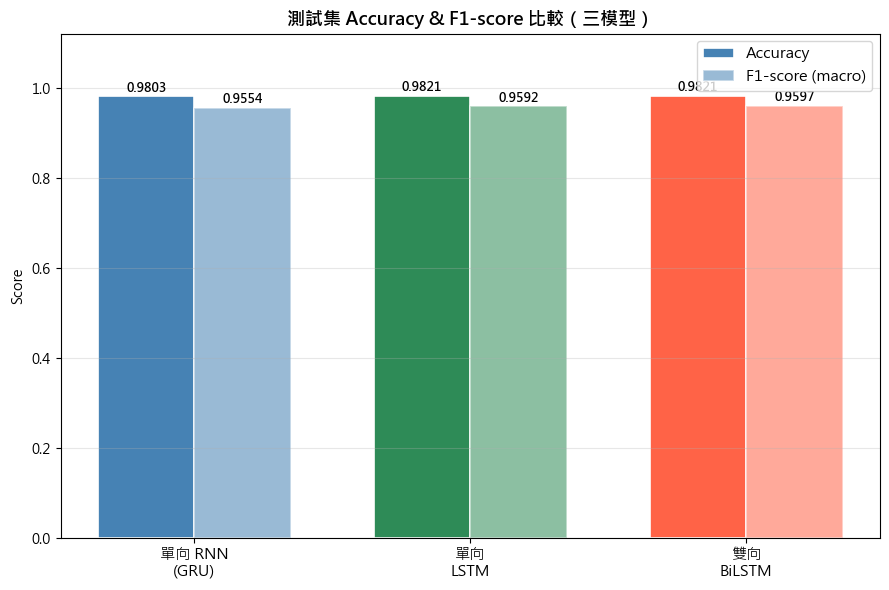

長條圖已儲存為 accuracy_f1_3models.png


In [12]:
model_names = ['單向 RNN\n(GRU)', '單向\nLSTM', '雙向\nBiLSTM']
accs = [rnn_acc, lstm_acc, bilstm_acc]
f1s  = [rnn_f1,  lstm_f1,  bilstm_f1]

x = np.arange(len(model_names))
w = 0.35

fig, ax = plt.subplots(figsize=(9, 6))
bars1 = ax.bar(x - w/2, accs, w, label='Accuracy',
               color=[colors['RNN'], colors['LSTM'], colors['BiLSTM']],
               edgecolor='white', linewidth=1.2)
bars2 = ax.bar(x + w/2, f1s,  w, label='F1-score (macro)',
               color=[colors['RNN'], colors['LSTM'], colors['BiLSTM']],
               edgecolor='white', linewidth=1.2, alpha=0.55)

for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.003,
            f'{h:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylim(0, 1.12)
ax.set_title('測試集 Accuracy & F1-score 比較（三模型）', fontsize=13, fontweight='bold')
ax.set_ylabel('Score')
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('accuracy_f1_3models.png', dpi=150, bbox_inches='tight')
plt.show()
print('長條圖已儲存為 accuracy_f1_3models.png')

## 12. 結論

在完全相同的超參數（Learning Rate=0.001、Epochs=15、Hidden Size=128、Num Layers=2）與訓練集下，三個模型的實驗結果如下。

---

### 測試集量化結果

| 模型 | Accuracy | F1-score (macro) |
|------|----------|------------------|
| 單向 RNN (GRU) | 0.9803 | 0.9554 |
| 單向 LSTM | 0.9821 | 0.9592 |
| 雙向 BiLSTM | **0.9821** | **0.9597** |

---

### Loss 下降曲線分析

由 Training / Validation Loss 曲線（見上方圖）可觀察到三種收斂特性：

- **單向 RNN (GRU)**：收斂速度最快，Training Loss 在第 6 個 Epoch 後即趨於平穩（≈ 0.020），Validation Loss 同步穩定於 0.040–0.051，訓練過程最為穩定，沒有明顯的 overfitting 跡象。
- **單向 LSTM**：收斂速度略慢於 GRU，Training Loss 於第 9 Epoch 後穩定（≈ 0.028），Validation Loss 最低點出現於第 9 Epoch（0.0437），之後略微上升並維持在 0.05–0.06 之間，整體穩定。
- **雙向 BiLSTM**：收斂最慢，Training Loss 持續下降至最低（第 13 Epoch ≈ 0.007），然而 Validation Loss 在第 10 Epoch 後反而逐漸回升（0.0575 → 0.0975），顯示出輕微的 overfitting 現象，訓練集與驗證集之間出現了明顯的 Loss gap。

---

### Accuracy / F1-score 長條圖分析

由長條圖（見上方圖）可見三個模型的測試集分數差距極小（< 0.5%）：

- **Accuracy**：LSTM 與 BiLSTM 同為 0.9821，GRU 以 0.9803 緊隨其後，差距僅 0.18%。
- **F1-score (macro)**：BiLSTM 以 0.9597 略勝 LSTM（0.9592）與 GRU（0.9554），但差距不超過 0.005。

---

### 綜合結論

1. **三模型差距極小**：在 SMS 垃圾簡訊這類短文本二元分類任務上，三者 Accuracy 相差不到 0.2%，F1-score 相差不到 0.5%，說明任務本身難度不高，各模型皆能有效學習。

2. **BiLSTM 在 F1 略勝但有 overfitting 傾向**：雖然 BiLSTM 的 F1-score 最高，但其 Validation Loss 在後期持續上升，顯示雙向結構的參數量（836,354，約為 GRU 的兩倍）在此資料集規模下略嫌過大，存在輕度過擬合。

3. **GRU 收斂最快且最穩定**：GRU 以最少的參數量（415,746）達到接近 LSTM 與 BiLSTM 的測試表現，並在訓練中保持最穩定的 Validation Loss，兼顧效率與效果。

4. **簡單模型已足夠**：對於此規模的短文本分類任務，單向 GRU 即可達到 98% 以上的準確率；若要進一步提升，可考慮更大的資料集、預訓練詞向量（如 GloVe）或 Transformer 架構，而非單純增加模型複雜度。